# KKBox Churn — EDA
Tables: `members` (static), `transactions` + `user_logs` (event logs).

## 1. Load & shape

In [2]:
import duckdb
import pandas as pd

In [25]:
pd.set_option("display.max_columns", None)
con = duckdb.connect('data/churn.duckdb')
q = lambda sql: con.execute(sql).df()
DATA = "data/"
# views over CSVs — user_logs is ~10s of M rows, don't pull into pandas

# members: static, single file
con.execute(f"CREATE VIEW members AS SELECT * FROM read_csv_auto('{DATA}members_v3.csv')")

# transactions + user_logs: union base history with the _v2 recent-month supplement.
con.execute(f"""
    CREATE VIEW transactions AS
    SELECT * FROM read_csv_auto('{DATA}transactions.csv')
    UNION ALL
    SELECT * FROM read_csv_auto('{DATA}transactions_v2.csv')
""")

con.execute(f"""
    CREATE VIEW user_logs AS
    SELECT * FROM read_csv_auto('{DATA}user_logs.csv')   -- the ~30GB one
    UNION ALL
    SELECT * FROM read_csv_auto('{DATA}user_logs_v2.csv')
""")

for t in ["members", "transactions", "user_logs"]:
    print(f"{t:13s} {con.execute(f'SELECT count(*) FROM {t}').fetchone()[0]:>14,} rows")

members            6,769,473 rows
transactions      22,978,755 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

user_logs        410,502,905 rows


#### load
- members 6.77M, txns 23.0M (base + v2), logs 410M (base + v2)
- unions ok, full history in

## 2a. Schema & first look

In [11]:
for t in ["members", "transactions", "user_logs"]:
    print(t, "\n", q(f"DESCRIBE {t}"), "\n")

for t in ["members", "transactions", "user_logs"]:
    print(t, "\n", q(f"SELECT * FROM {t} LIMIT 5"), "\n")

members 
               column_name column_type null   key default extra
0                    msno     VARCHAR  YES  None    None  None
1                    city      BIGINT  YES  None    None  None
2                      bd      BIGINT  YES  None    None  None
3                  gender     VARCHAR  YES  None    None  None
4          registered_via      BIGINT  YES  None    None  None
5  registration_init_time      BIGINT  YES  None    None  None 

transactions 
               column_name column_type null   key default extra
0                    msno     VARCHAR  YES  None    None  None
1       payment_method_id      BIGINT  YES  None    None  None
2       payment_plan_days      BIGINT  YES  None    None  None
3         plan_list_price      BIGINT  YES  None    None  None
4      actual_amount_paid      BIGINT  YES  None    None  None
5           is_auto_renew      BIGINT  YES  None    None  None
6        transaction_date      BIGINT  YES  None    None  None
7  membership_expire_date   

#### schema
- key = msno (varchar) in all 3, consistent -> joins won't break on type
- ALL dates are YYYYMMDD ints (reg_init_time, transaction_date, membership_expire_date, logs.date) -> cast to real date before any time math  [open]
- city / registered_via / payment_method_id = ints but really category codes -> encode, don't scale
- is_auto_renew, is_cancel = 0/1 flags
- bd = ?? mostly 0 + one 32, 0 looks like a placeholder -> check dict + distribution later
- gender = lots of None (missing)

## 2b. Grain

In [8]:
print(q("SELECT count(*) n_rows, count(DISTINCT msno) users FROM members"))

print(q("""
    WITH per_user AS (SELECT msno, count(*) n FROM transactions GROUP BY msno)
    SELECT count(*) users, min(n) min_txn, max(n) max_txn,
           quantile_cont(n,0.5) median_txn, round(avg(n),2) mean_txn,
           sum((n=1)::int) users_1txn
    FROM per_user
"""))

# slow: full scan of ~410M rows
print(q("SELECT count(*) n_rows, count(DISTINCT msno) users FROM user_logs"))
print(q("""SELECT count(*) dup_user_days
           FROM (SELECT msno, date FROM user_logs GROUP BY msno, date HAVING count(*)>1)"""))

    n_rows    users
0  6769473  6769473


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

     users  min_txn  max_txn  median_txn  mean_txn  users_1txn
0  2426143        1      244         5.0      9.47    558844.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      n_rows    users
0  410502905  5339422


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   dup_user_days
0              0


#### grain
- members unique on msno -> static, join direct
- txns: 2.43M distinct users = population i can actually model (need an expiry, lives here), NOT 6.77M -> build spine FROM txns, left join members   <- big one
  - txn/user skewed: med 5, mean 9.5, max 244; 559k users (23%) have 1 txn -> thin history for them
- logs: 0 dup (msno,date) -> clean daily grain, no dedup. (earlier "logs have dupes" = wrong, checked)
- logs users 5.34M > txn users 2.43M (lots of free listeners)

In [12]:
# slow: distinct over ~410M log rows
print(q("""
    WITH spine AS (SELECT DISTINCT msno FROM transactions)
    SELECT count(*) txn_users, count(m.msno) also_in_members, count(l.msno) also_in_logs
    FROM spine s
    LEFT JOIN (SELECT DISTINCT msno FROM members)   m USING (msno)
    LEFT JOIN (SELECT DISTINCT msno FROM user_logs) l USING (msno)
"""))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   txn_users  also_in_members  also_in_logs
0    2426143          1988333       1938231


#### coverage (spine = 2.43M txn users)
- in members: 1.99M (82%) -> 438k (18%) have no demographics
- in logs: 1.94M (80%) -> 488k (20%) have no listening logs at all
- members_v3 is NOT a superset of transactors
- assembly: spine LEFT JOIN members LEFT JOIN agg(logs), keep all 2.43M, never inner (biases to data-rich)
- no-logs might = truly inactive not missing -> maybe a flag, not zero-fill  [revisit @ features]

In [13]:
print(q("""SELECT min(transaction_date) first_txn, max(transaction_date) last_txn,
                  min(membership_expire_date) first_exp, max(membership_expire_date) last_exp
           FROM transactions"""))
print(q("SELECT min(date) first_log, max(date) last_log FROM user_logs"))  # slow: full scan

   first_txn  last_txn  first_exp  last_exp
0   20150101  20170331   19700101  20361015


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   first_log  last_log
0   20150101  20170331


#### dates
- txn + logs both 2015-01-01 .. 2017-03-31, aligned. good
- horizon = 2017-03-31. need +30d after expiry to label -> can only self-label expiries up to ~mar 1 2017
  - march ones need train_v2 (kkbox had april data, we don't)
- expire_date: min 19700101 (??), max 20361015 -> junk, and it's the cutoff so it matters -> how many bad rows? (next cell)
- txn_date fine

In [14]:
print(q("""
    SELECT count(*) n_txn,
           sum((membership_expire_date < 20150101)::int)                  exp_before_2015,
           sum((membership_expire_date BETWEEN 20150101 AND 20171231)::int) exp_in_range,
           sum((membership_expire_date > 20171231)::int)                  exp_after_2017,
           quantile_cont(membership_expire_date,0.5)  median_exp,
           quantile_cont(membership_expire_date,0.99) p99_exp
    FROM transactions
"""))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      n_txn  exp_before_2015  exp_in_range  exp_after_2017  median_exp  \
0  22978755           9840.0    22892648.0         76267.0  20160527.0   

      p99_exp  
0  20170530.0  


#### expiry sanity
- bad expiries tiny: ~10k before 2015 (0.04%), ~76k after 2017 (0.33%) = ~0.4% total
- bulk sane: median 2016-05, p99 2017-05
- all junk sits outside labelable window -> the expiry<=~2017-03-01 filter removes them for free, no extra cleaning

In [15]:
print(q("""SELECT count(*) n, sum(is_churn) churners, avg(is_churn) churn_rate
           FROM read_csv_auto('data/train_v2.csv')"""))

        n  churners  churn_rate
0  970960   87330.0    0.089942


#### base rate (train_v2 = kkbox labels, mar-2017 cohort)
- churn ~9% (87,330 / 970,960), imbalance ~10:1
- => accuracy useless ("all renew" = 91%); report PR-AUC; ROC-AUC flattered by TNs
- => need calibrated probs (threshold ~0.63 plugs P(churn) into money)
- caveat: one month, kkbox def. our own full-window label may differ -> cross-check later

In [16]:
print(q("""WITH s AS (SELECT msno FROM transactions GROUP BY msno
                      HAVING count(*) BETWEEN 6 AND 12 AND max(is_cancel)=1 LIMIT 2)
           SELECT t.msno, transaction_date txn_dt, membership_expire_date exp_dt,
                  payment_plan_days plan_days, plan_list_price list, actual_amount_paid paid,
                  is_auto_renew auto, is_cancel cancel
           FROM transactions t JOIN s USING (msno) ORDER BY t.msno, transaction_date"""))

print(q("""WITH s AS (SELECT msno FROM transactions GROUP BY msno
                      HAVING count(*) BETWEEN 6 AND 12 AND max(is_cancel)=0 LIMIT 1)
           SELECT t.msno, transaction_date txn_dt, membership_expire_date exp_dt,
                  payment_plan_days plan_days, plan_list_price list, actual_amount_paid paid,
                  is_auto_renew auto, is_cancel cancel
           FROM transactions t JOIN s USING (msno) ORDER BY t.msno, transaction_date"""))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                                            msno    txn_dt    exp_dt  \
0   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI=  20150119  20150220   
1   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI=  20150219  20150320   
2   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI=  20150319  20150420   
3   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI=  20150419  20150520   
4   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI=  20150519  20150620   
5   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI=  20150619  20150720   
6   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI=  20150719  20150820   
7   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI=  20150821  20150920   
8   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI=  20150919  20151020   
9   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI=  20151020  20151020   
10  yNSno1HIIdIeDrpLedFFYsZ9/s39qZodDLLtNmsWKB0=  20160519  20160618   
11  yNSno1HIIdIeDrpLedFFYsZ9/s39qZodDLLtNmsWKB0=  20160618  20160718   
12  yNSno1HIIdIeDrpLedFFYsZ9/s39qZodDLLtNmsWKB0=  20160718  2016

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                                           msno    txn_dt    exp_dt  \
0  gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I=  20150410  20150510   
1  gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I=  20151007  20151106   
2  gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I=  20151116  20151216   
3  gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I=  20160121  20160220   
4  gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I=  20160509  20160608   
5  gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I=  20160930  20161030   

   plan_days  list  paid  auto  cancel  
0         30   149   149     0       0  
1         30   149   149     0       0  
2         30   149   149     0       0  
3         30   149   149     0       0  
4         30   149   149     0       0  
5         30   149   149     0       0  


#### txn mechanics (3 sample users)
- normal active life = monthly auto-renew (auto=1), renews ~1d BEFORE expiry, continuous membership
- cancel (is_cancel=1) is just a txn; it can pull exp_dt EARLIER (user2: 12-18 -> 11-24)
- cancel != churn: user2 cancelled then bought a 195d plan 6d later -> stayed
- "clean" no-cancel user (user3) churned & resurrected ~4x -> CHURN = a >30d gap after expiry, NOT the cancel flag
- governing expiry at time T = exp_dt of the LATEST txn by txn_dt (handles cancels). tie-break for same-day? [check]
- plan length varies (30 vs 195d), price scales with it

In [17]:
print(q("""SELECT count(*) same_day_groups FROM
           (SELECT msno, transaction_date FROM transactions
            GROUP BY msno, transaction_date HAVING count(*)>1)"""))

print(q("""WITH d AS (SELECT msno, transaction_date FROM transactions
                      GROUP BY msno, transaction_date HAVING count(*)>1 LIMIT 4)
           SELECT t.msno, transaction_date txn_dt, membership_expire_date exp_dt,
                  payment_plan_days plan_days, actual_amount_paid paid,
                  is_auto_renew auto, is_cancel cancel
           FROM transactions t JOIN d USING (msno, transaction_date)
           ORDER BY t.msno, t.membership_expire_date"""))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   same_day_groups
0           289730


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                                           msno    txn_dt    exp_dt  \
0  BrTVBIlFgFlV6++voS6K0PvpAPH7l4TL8gV8OZ6lFC4=  20150618  20150617   
1  BrTVBIlFgFlV6++voS6K0PvpAPH7l4TL8gV8OZ6lFC4=  20150618  20150717   
2  I0dcJSphyw5nKzD4wde39puTjX762gYIado+KimX4Mk=  20160225  20160225   
3  I0dcJSphyw5nKzD4wde39puTjX762gYIado+KimX4Mk=  20160225  20160325   
4  Wu7k8eUXuA/gxT2jxW6O5ofs8i6mIhQGYIlLxm09fXg=  20150526  20150524   
5  Wu7k8eUXuA/gxT2jxW6O5ofs8i6mIhQGYIlLxm09fXg=  20150526  20150625   
6  qs8AipTDuvhCbm3wc3Lp37+b+qTyR5nWN3wfLwCMUUo=  20150102  20150102   
7  qs8AipTDuvhCbm3wc3Lp37+b+qTyR5nWN3wfLwCMUUo=  20150102  20150202   

   plan_days  paid  auto  cancel  
0         30   149     1       1  
1         30   129     1       0  
2         30   149     1       1  
3          7     0     0       0  
4         30   149     1       1  
5         30   149     1       0  
6         30   149     1       1  
7         30   119     1       0  


#### same-day txns
- 289,730 (msno, txn_dt) groups have >1 row -> need a rule, not rare
- pattern (all samples): same-day CANCEL + PURCHASE; cancel row = earlier exp, purchase = later exp
  (some repurchases discounted/free: 129/119/0 for 7d -> promo/winback)
- rule: per (msno, txn_dt) keep MAX(exp_dt) = the day's net paid-through
- why: else the cancel's pulled-back expiry = phantom point w/ no renewal -> ~289k FALSE churns
- forces date cast now: YYYYMMDD int -> DATE for E+30

In [20]:
sample = ['ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI=',
          'yNSno1HIIdIeDrpLedFFYsZ9/s39qZodDLLtNmsWKB0=',
          'gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I=']
in_list = ",".join(f"'{m}'" for m in sample)

print(q(f"""
WITH per_day AS (
    SELECT msno, strptime(transaction_date::VARCHAR,'%Y%m%d')::DATE txn_dt,
           max(strptime(membership_expire_date::VARCHAR,'%Y%m%d')::DATE) exp_dt
    FROM transactions GROUP BY msno, transaction_date),
pts AS (SELECT msno, exp_dt expiry, max(txn_dt) gov_txn FROM per_day GROUP BY msno, exp_dt),
labeled AS (
    SELECT p.msno, p.expiry, p.gov_txn,
      NOT EXISTS (SELECT 1 FROM per_day d WHERE d.msno=p.msno AND d.txn_dt>p.gov_txn
                  AND d.txn_dt<=p.expiry+30 AND d.exp_dt>p.expiry) is_churn,
      (p.expiry+30 <= DATE '2017-03-31' AND p.expiry >= DATE '2015-01-01') labelable
    FROM pts p)
SELECT * FROM labeled WHERE msno IN ({in_list}) ORDER BY msno, expiry
"""))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                                            msno     expiry    gov_txn  \
0   gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I= 2015-05-10 2015-04-10   
1   gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I= 2015-11-06 2015-10-07   
2   gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I= 2015-12-16 2015-11-16   
3   gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I= 2016-02-20 2016-01-21   
4   gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I= 2016-06-08 2016-05-09   
5   gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I= 2016-10-30 2016-09-30   
6   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI= 2015-02-20 2015-01-19   
7   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI= 2015-03-20 2015-02-19   
8   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI= 2015-04-20 2015-03-19   
9   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI= 2015-05-20 2015-04-19   
10  ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI= 2015-06-20 2015-05-19   
11  ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI= 2015-07-20 2015-06-19   
12  ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpA

#### label logic verified (3 hand-checked users)
- user1: churn only at 2015-10-20 ✓; user3: churns 05-10/12-16/02-20/06-08/10-30, renew 11-06 ✓
- user2: in-window all renewed; 2016-12-18 NOT false churn (long plan supersedes) ✓; 2017-06-12 labelable=False ✓
- minor: user2 has both 11-24 & 12-18 (both renewed) -> slight over-count, not false labels, acceptable

In [21]:
q("""
CREATE OR REPLACE TABLE pred_points AS
WITH per_day AS (
    SELECT msno, strptime(transaction_date::VARCHAR,'%Y%m%d')::DATE AS txn_dt,
           max(strptime(membership_expire_date::VARCHAR,'%Y%m%d')::DATE) AS exp_dt
    FROM transactions GROUP BY msno, transaction_date),
pts AS (SELECT msno, exp_dt AS expiry, max(txn_dt) AS gov_txn FROM per_day GROUP BY msno, exp_dt),
labeled AS (
    SELECT p.msno, p.expiry, p.gov_txn,
      NOT EXISTS (SELECT 1 FROM per_day d WHERE d.msno=p.msno AND d.txn_dt>p.gov_txn
                  AND d.txn_dt<=p.expiry+30 AND d.exp_dt>p.expiry) AS is_churn,
      (p.expiry+30 <= DATE '2017-03-31' AND p.expiry >= DATE '2015-01-01') AS labelable
    FROM pts p)
SELECT msno, expiry, gov_txn, is_churn,
       date_trunc('month', expiry) AS cohort_month     -- monthly cohort key, for the temporal split later
FROM labeled
WHERE labelable
""")

print(q("""SELECT count(*) AS n_points, count(DISTINCT msno) AS n_users,
                  sum(is_churn::int) AS churns, avg(is_churn::int) AS churn_rate
           FROM pred_points"""))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   n_points  n_users     churns  churn_rate
0  19976745  2322839  2108966.0    0.105571


#### own label built (pred_points)
- 19.98M labelable points, 2.32M users, churn_rate = 10.6% (per CYCLE)
- cross-check: train_v2 (kkbox, per-user, 1 month) = 9% -> same ballpark -> independent label validated
- my "lower than 9%" guess was wrong: resurrectors log repeated churns + ~559k one-and-done users push it up
- 20M rows >> needed -> sample later (few hundred k)

   cohort_month        n    churns  churn_rate
0    2015-01-01    24513   17611.0      0.7184
1    2015-02-01   416861   29603.0      0.0710
2    2015-03-01   525961   31853.0      0.0606
3    2015-04-01   602232  104209.0      0.1730
4    2015-05-01   548844   39738.0      0.0724
5    2015-06-01   705633  189867.0      0.2691
6    2015-07-01   616104   37709.0      0.0612
7    2015-08-01   657732   44470.0      0.0676
8    2015-09-01   689100   69855.0      0.1014
9    2015-10-01   712293   65372.0      0.0918
10   2015-11-01   759326   83336.0      0.1097
11   2015-12-01   835855  119675.0      0.1432
12   2016-01-01   856111  119583.0      0.1397
13   2016-02-01   776897   89221.0      0.1148
14   2016-03-01   890102  168306.0      0.1891
15   2016-04-01   792723   71649.0      0.0904
16   2016-05-01   798960   69610.0      0.0871
17   2016-06-01   800934   60678.0      0.0758
18   2016-07-01   837175   69375.0      0.0829
19   2016-08-01   879716   53067.0      0.0603
20   2016-09-

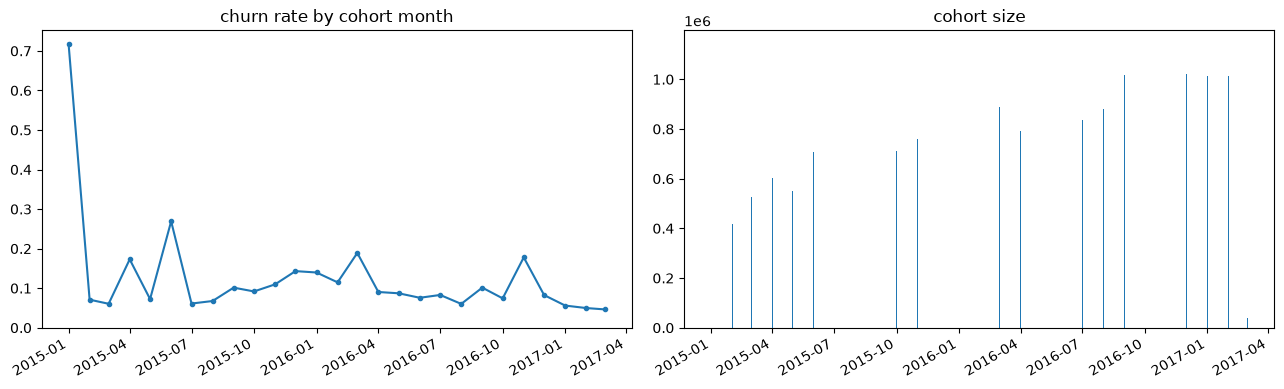

In [22]:
import matplotlib.pyplot as plt
m = q("""SELECT cohort_month, count(*) AS n, sum(is_churn::int) AS churns,
                round(avg(is_churn::int),4) AS churn_rate
         FROM pred_points GROUP BY cohort_month ORDER BY cohort_month""")
print(m)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(m['cohort_month'], m['churn_rate'], marker='.'); ax[0].set_title('churn rate by cohort month'); ax[0].set_ylim(0, None)
ax[1].bar(m['cohort_month'], m['n']); ax[1].set_title('cohort size'); fig.autofmt_xdate(); plt.tight_layout(); plt.show()

#### churn rate by cohort month
- 2015-01: 24k rows, 72% churn -> LEFT-CENSORING edge (data starts 2015-01-01) -> DROP
- 2017-03: 39k rows -> partial (only expiry<=03-01 labelable) -> DROP / not a full month
- rate volatile ~5-27%; spikes 2015-04(17%), 2015-06(27%), 2016-03(19%), 2016-11(18%) -> likely promo/trial waves
- mild downward drift into 2017 (jan 5.6%, feb 5.0%)
- implication: val/test must be multi-month BLOCKS so one spike can't dominate a split

In [23]:
print(q("""
WITH g AS (
    SELECT p.cohort_month, p.is_churn,
           CASE WHEN t.payment_plan_days <= 7 THEN 'trial (<=7d)'
                WHEN t.payment_plan_days <= 31 THEN 'monthly'
                ELSE 'long (>31d)' END AS plan_bucket,
           (t.actual_amount_paid = 0) AS is_free
    FROM pred_points p
    JOIN transactions t
      ON t.msno = p.msno
     AND t.transaction_date = strftime(p.gov_txn,'%Y%m%d')::INT
     AND t.membership_expire_date = strftime(p.expiry,'%Y%m%d')::INT
    WHERE p.cohort_month IN (DATE '2015-06-01', DATE '2016-08-01'))
SELECT cohort_month, plan_bucket, is_free, count(*) AS n, round(avg(is_churn::int),3) AS churn_rate
FROM g GROUP BY cohort_month, plan_bucket, is_free ORDER BY cohort_month, n DESC
"""))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   cohort_month   plan_bucket  is_free       n  churn_rate
0    2015-06-01  trial (<=7d)    False  287163       0.031
1    2015-06-01       monthly    False  245818       0.084
2    2015-06-01  trial (<=7d)     True  165402       0.932
3    2015-06-01       monthly     True    8326       0.723
4    2015-06-01   long (>31d)    False     640       0.327
5    2015-06-01   long (>31d)     True     154       0.214
6    2016-08-01       monthly    False  837174       0.042
7    2016-08-01   long (>31d)    False   18668       0.281
8    2016-08-01  trial (<=7d)     True   16567       0.449
9    2016-08-01       monthly     True    7683       0.673
10   2016-08-01  trial (<=7d)    False     518       0.079
11   2016-08-01   long (>31d)     True     143       0.315


#### 2015-06 spike = promo wave (confirmed)
- driver: 165k FREE 7-day trials @ 93% churn (calm 2016-08 had only ~16.5k such)
- free flag is the line: free trial 93% / free monthly 72% vs paid monthly ~4-8%
- paid-monthly core stable-ish both months -> spike is COMPOSITION, not model/pipeline issue
- => is_free / trial-status = top churn feature, point-in-time safe [add at feature build]
- => free-trial conversion vs paid retention ~ two problems in one model (note for interview)

In [24]:
q("""
CREATE OR REPLACE TABLE cohorts AS
SELECT *,
       CASE WHEN cohort_month <= DATE '2016-08-01' THEN 'train'
            WHEN cohort_month <= DATE '2016-11-01' THEN 'val'
            ELSE 'test' END AS split
FROM pred_points
WHERE cohort_month BETWEEN DATE '2015-02-01' AND DATE '2017-02-01'
""")
print(q("""SELECT split, count(*) AS n, count(DISTINCT msno) AS users,
                  round(avg(is_churn::int),4) AS churn_rate
           FROM cohorts GROUP BY split ORDER BY min(cohort_month)"""))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   split         n    users  churn_rate
0  train  13702559  1839060      0.1107
1    val   3163206  1316470      0.1203
2   test   3047236  1154746      0.0629


#### temporal split locked (cohorts table)
- train 13.7M (69%) @ 11.1% | val 3.16M (16%) @ 12.0% | test 3.05M (15%) @ 6.3%
- test base rate ~half of train/val = the real downward drift, NOT an error -> KEEP (equalizing = hiding reality)
- consequences: PR-AUC not directly comparable across splits; calibration/threshold tuned @ ~11% need adjusting @ 6%
- => concrete motivation for prior/label-shift monitoring in phase F